# Processamento de Sinais I — Aula Prática 2
## Questão 10 — Resposta do sistema `h_banheiro[n]` para diferentes entradas

Objetivo: calcular a saída do sistema descrito por `h_banheiro[n]` quando a entrada é `handel.wav` e quando a entrada é `sinal_taca.wav`, calcular os espectros das respostas e comentar os resultados.

Observação importante: para convoluir, os sinais precisam estar na mesma frequência de amostragem.

## Importar bibliotecas e carregar a função de espectro

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.io import wavfile
from scipy import signal

def load_calculate_spectrum():
    notebook_path = Path('../tools/calculate_spectrum.ipynb')
    notebook = json.loads(notebook_path.read_text(encoding='utf-8'))

    namespace = {}
    for cell in notebook['cells']:
        if cell.get('cell_type') != 'code':
            continue

        source = ''.join(cell.get('source', []))
        exec(source, namespace)
        if 'calculate_spectrum' in namespace:
            return namespace['calculate_spectrum']

    raise RuntimeError('calculate_spectrum() nao encontrada em ../tools/calculate_spectrum.ipynb')

calculate_spectrum = load_calculate_spectrum()

plt.style.use('seaborn-v0_8-whitegrid')

def to_float_mono(data):
    data = np.asarray(data)
    if data.ndim > 1:
        data = data.mean(axis=1)
    if np.issubdtype(data.dtype, np.integer):
        data = data.astype(np.float64) / np.iinfo(data.dtype).max
    else:
        data = data.astype(np.float64)
    peak = np.max(np.abs(data))
    if peak > 1:
        data = data / peak
    return data


def show_audio(audio, rate, label):
    print(label)
    display(Audio(audio, rate=rate))


def plot_spectrum(signal_in, sampling_frequency, title, max_frequency=None):
    freqs, amps = calculate_spectrum(signal_in, sampling_frequency, single_sided=True)
    plt.figure(figsize=(12, 4))
    plt.plot(freqs, amps)
    if max_frequency is not None:
        plt.xlim(0, max_frequency)
    plt.title(title)
    plt.xlabel('Frequencia (Hz)')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    return freqs, amps


## Ler os sinais e igualar as frequências de amostragem

In [2]:
fs_h, h_int = wavfile.read('../data/h_banheiro.wav')
fs_t, taca_int = wavfile.read('../data/sinal_taca.wav')
fs_audio, handel_int = wavfile.read('../data/handel.wav')

h = to_float_mono(h_int)
taca = to_float_mono(taca_int)
handel = to_float_mono(handel_int)

# A resposta ao impulso e a taca ja estao em 22050 Hz.
# O audio musical e reamostrado para essa mesma taxa.
if fs_audio != fs_h:
    handel = signal.resample(handel, int(round(len(handel) * fs_h / fs_audio)))

fs = fs_h


## Convoluir, visualizar, ouvir e calcular o espectro

Audio: Saida para handel.wav


Audio: Saida para sinal_taca.wav


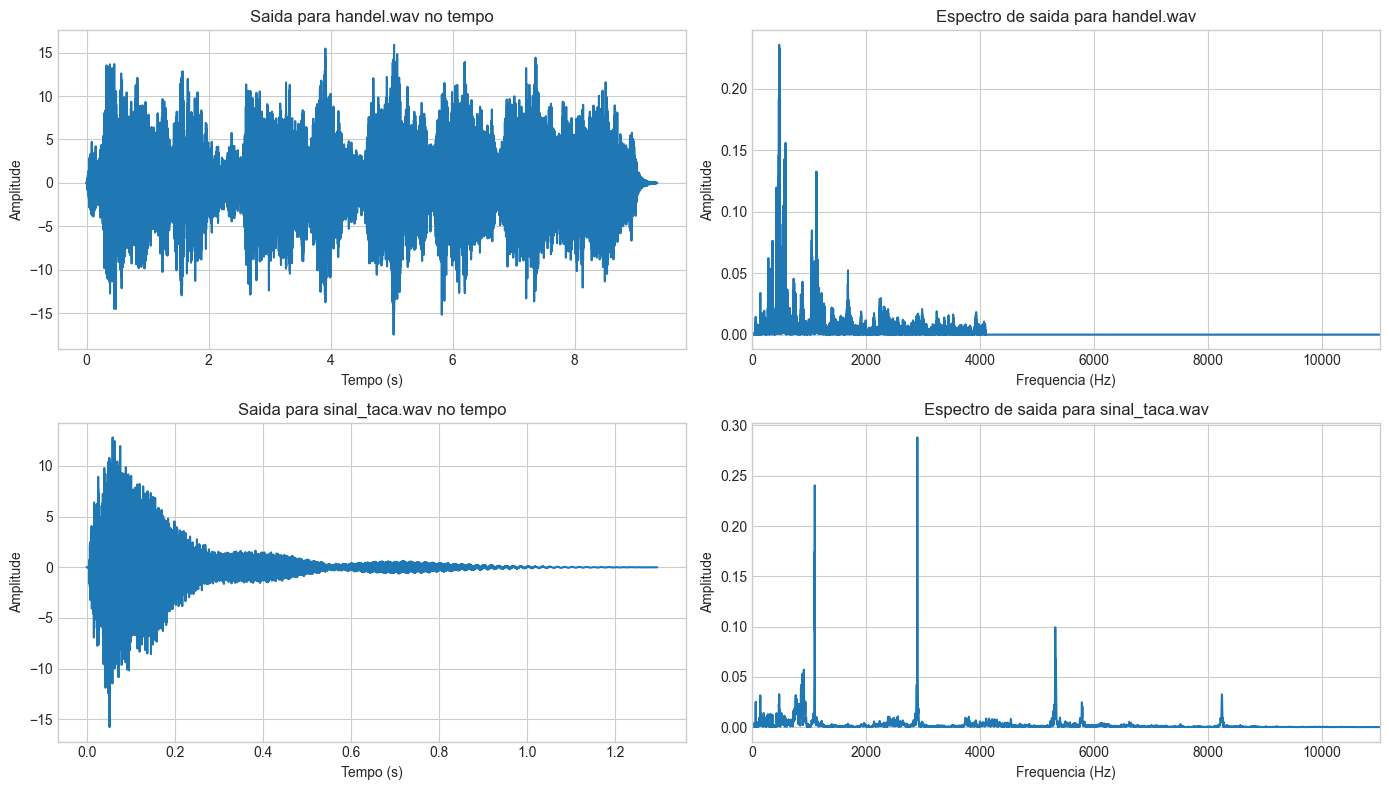

In [3]:
resposta_handel = signal.fftconvolve(handel, h, mode='full')
resposta_taca = signal.fftconvolve(taca, h, mode='full')

sinais_saida = {
    'Saida para handel.wav': resposta_handel,
    'Saida para sinal_taca.wav': resposta_taca,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, (nome, y) in enumerate(sinais_saida.items()):
    tempo = np.arange(len(y)) / fs
    axes[i, 0].plot(tempo, y)
    axes[i, 0].set_title(f'{nome} no tempo')
    axes[i, 0].set_xlabel('Tempo (s)')
    axes[i, 0].set_ylabel('Amplitude')

    freqs, amps = calculate_spectrum(y, fs, single_sided=True)
    axes[i, 1].plot(freqs, amps)
    axes[i, 1].set_xlim(0, fs / 2)
    axes[i, 1].set_title(f'Espectro de {nome.lower()}')
    axes[i, 1].set_xlabel('Frequencia (Hz)')
    axes[i, 1].set_ylabel('Amplitude')

    y_norm = y / np.max(np.abs(y))
    show_audio(y_norm, fs, f'Audio: {nome}')

plt.tight_layout()


## Comentários

A convolução com `h_banheiro[n]` faz os sinais de entrada adquirirem a assinatura acústica do ambiente. No domínio do tempo, as saídas ficam mais longas por causa das reflexões e da reverberação.

No espectro, a resposta ao impulso modifica a distribuição de energia do sinal de entrada. Na audição, o efeito percebido é o som sendo reproduzido como se estivesse dentro do banheiro, com reverberação mais evidente no material musical e também no toque da taça.